Loading data from REVERSAL STRATEGY MANUAL DATA.xlsx...
Generating Individual Pair Charts...
Saved 'auto_pairs_barcharts.png'
Generating Combined Sum Chart...
Saved 'auto_combined_sum.png'
All tasks completed successfully!


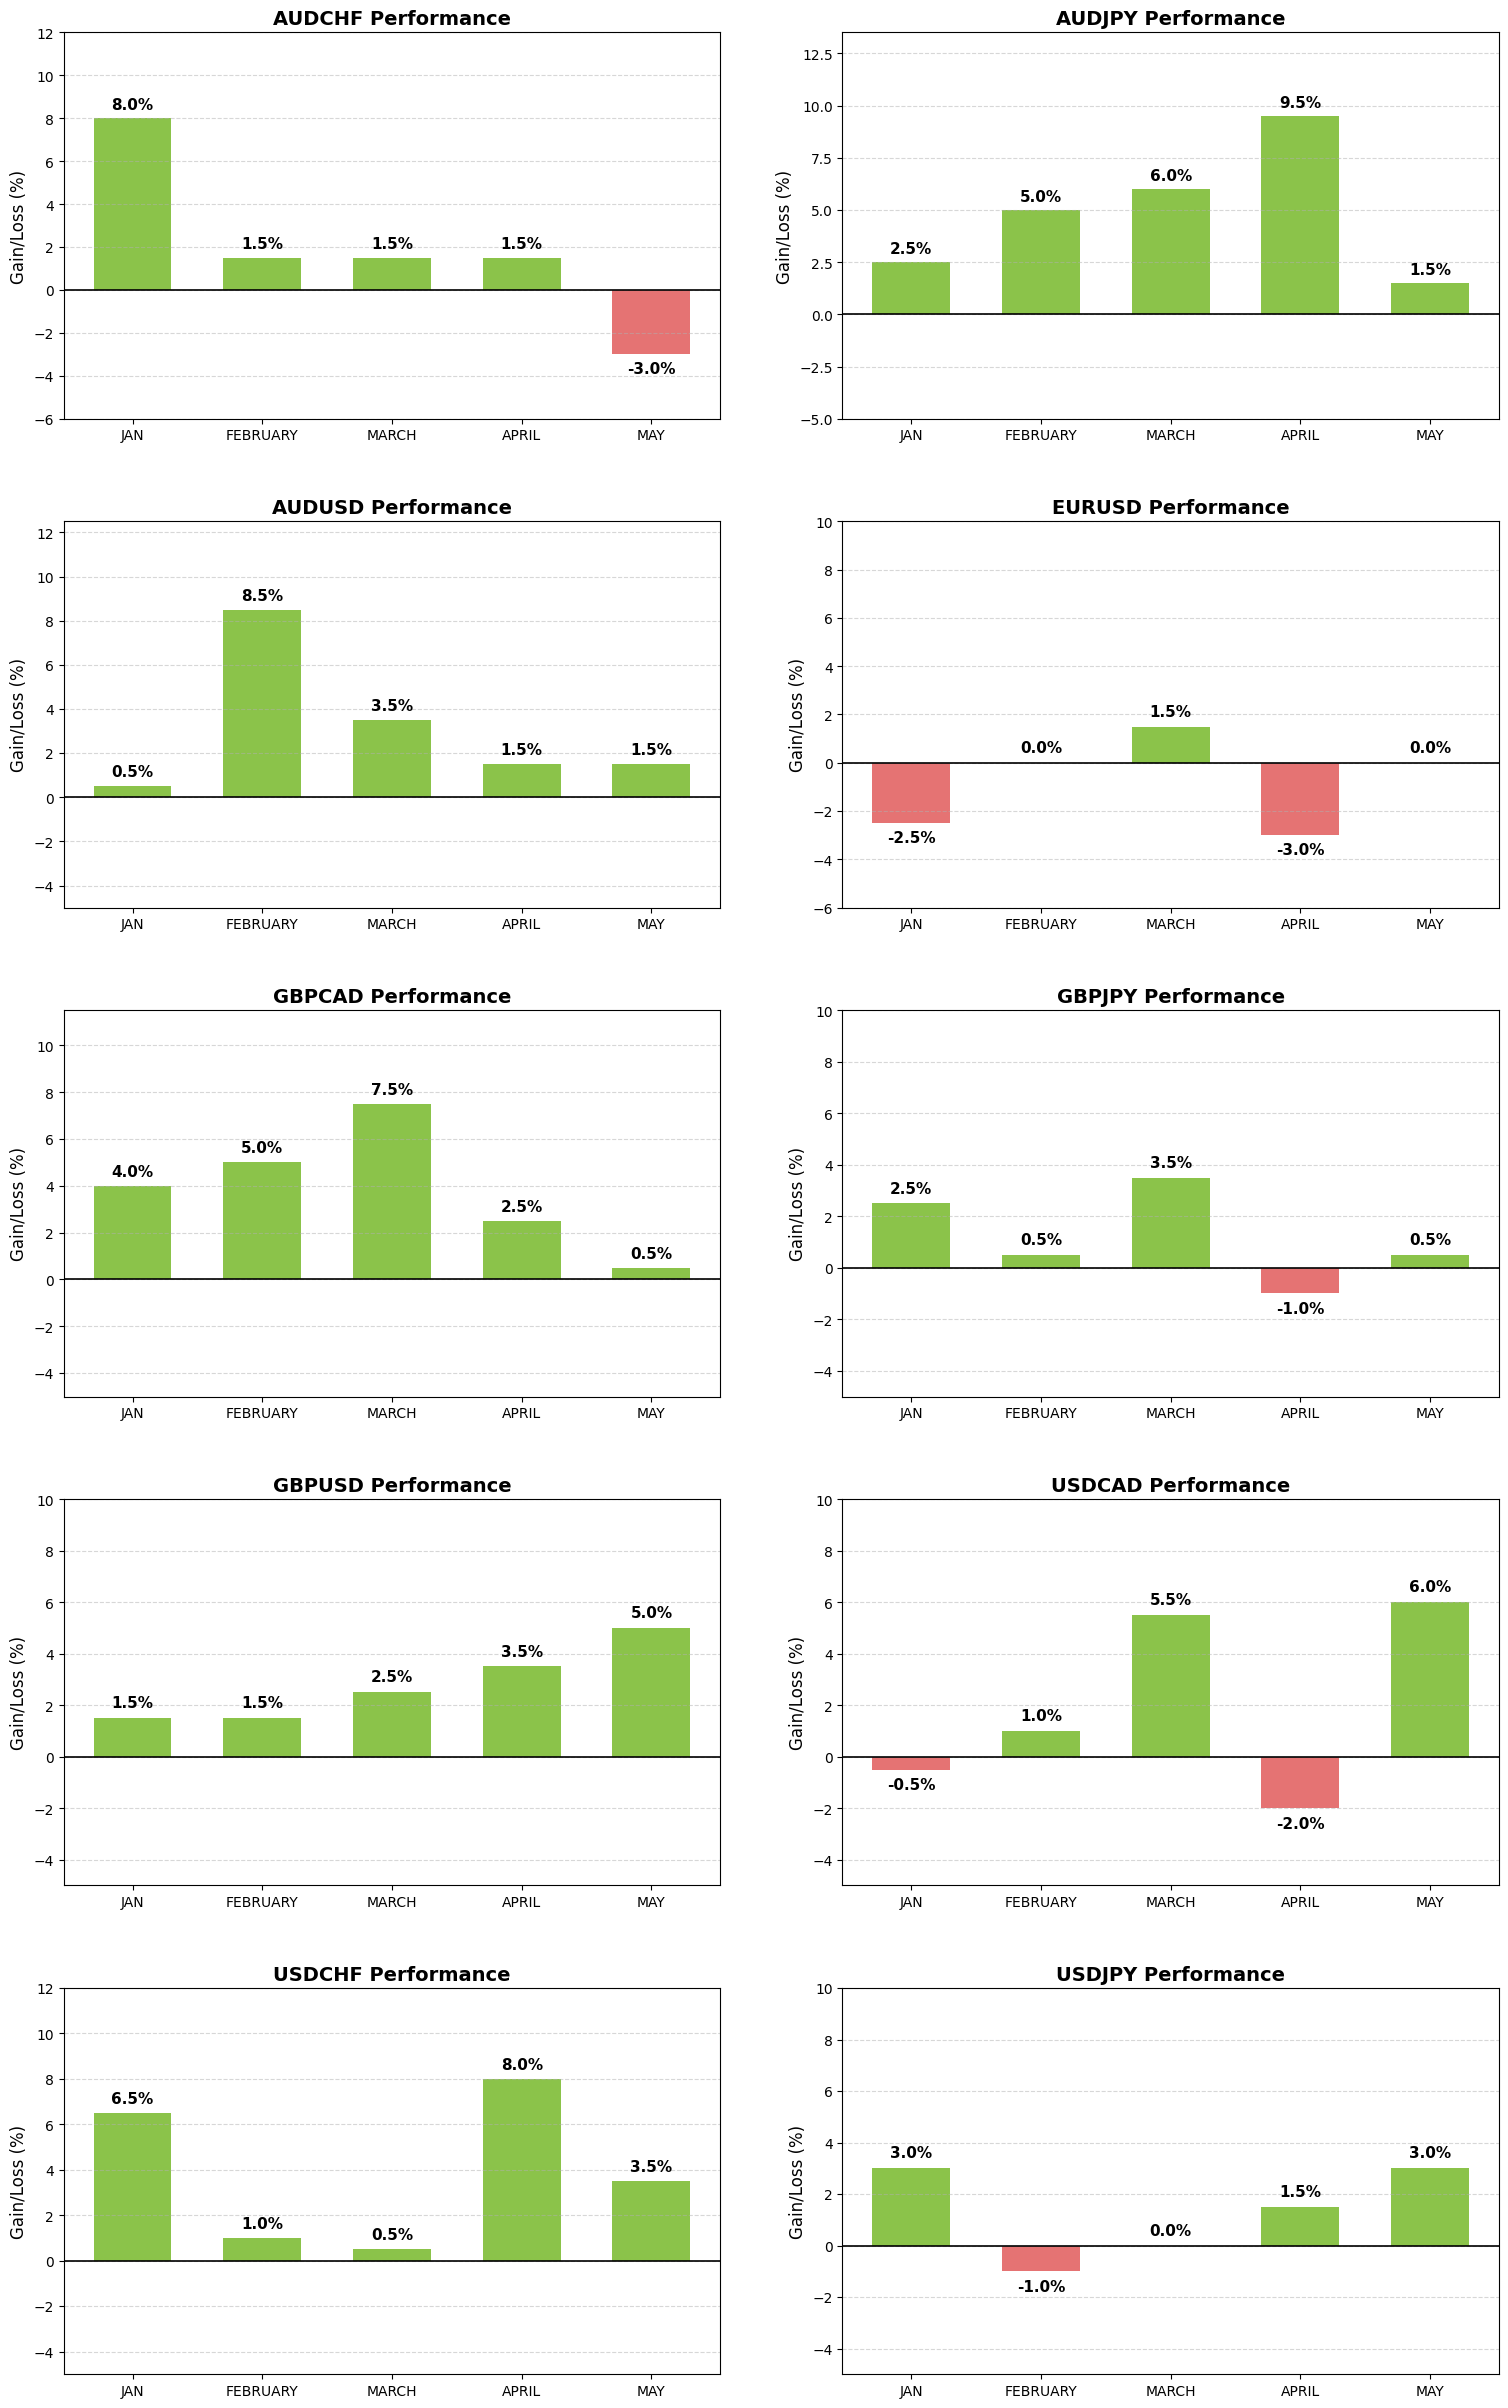

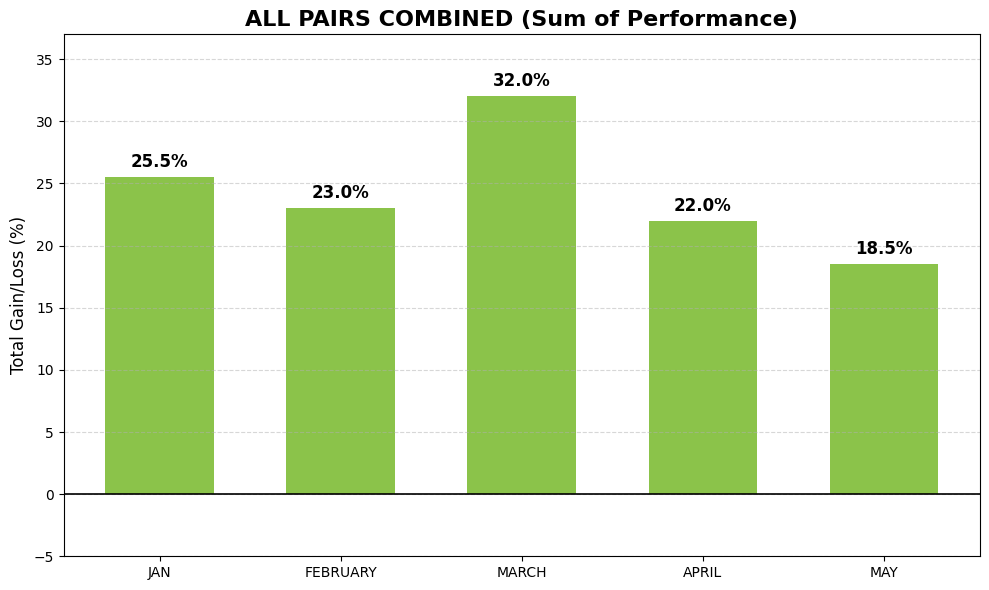

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

# --- 1. CONFIGURATION ---
FILE_PATH = 'REVERSAL STRATEGY MANUAL DATA.xlsx'
# If you want the script to calculate the % from your L.B.P scores instead of trusting the typed %, set this to True
CALCULATE_FROM_SCORE = False


def calculate_percentage_from_lbp(score_str):
    """Calculates the percentage gain/loss based on the L.B.P format."""
    try:
        if pd.isna(score_str):
            return 0.0

        # Split the L.B.P string (e.g., "2.1.4")
        l, b, p = map(int, str(score_str).split('.'))

        # Apply your rules
        loss_percent = l * -1.0
        breakeven_percent = math.floor(b / 2) * 1.0
        profit_percent = p * 2.5

        return loss_percent + breakeven_percent + profit_percent
    except Exception as e:
        return 0.0  # Return 0 if the cell is empty or incorrectly formatted


def main():
    # --- 2. DATA EXTRACTION ---
    print(f"Loading data from {FILE_PATH}...")
    df = pd.read_excel(FILE_PATH)

    # Assuming Column 0 is 'PAIR'
    # In your format, every odd index (1, 3, 5) is the Month %, every even (2, 4, 6) is the L.B.P score
    month_cols = df.columns[1::2]
    score_cols = df.columns[2::2]

    # Create a clean DataFrame specifically for the percentages
    df_clean = pd.DataFrame({'PAIR': df.iloc[:, 0]})

    for i, month in enumerate(month_cols):
        if CALCULATE_FROM_SCORE and i < len(score_cols):
            # Calculate from the L.B.P column automatically
            df_clean[month] = df[score_cols[i]].apply(
                calculate_percentage_from_lbp)
        else:
            # Just use the percentage you already typed in the month column
            df_clean[month] = df[month]

    pairs = df_clean['PAIR'].dropna().unique()
    months = df_clean.columns[1:]

    # --- 3. INDIVIDUAL PAIR CHARTS ---
    print("Generating Individual Pair Charts...")

    # Dynamically adjust grid size based on how many pairs you have
    num_pairs = len(pairs)
    cols = 2
    rows = math.ceil(num_pairs / cols)

    # Dynamically adjust width based on how many months you add
    chart_width = max(16, len(months) * 2)

    fig, axes = plt.subplots(nrows=rows, ncols=cols,
                             figsize=(chart_width, rows * 5))
    axes = axes.flatten()

    for i, pair in enumerate(pairs):
        ax = axes[i]
        pair_data = df_clean[df_clean['PAIR'] == pair].iloc[0, 1:]

        # Colors: Green for profit, Red for loss, Grey for breakeven
        colors = ['#8BC34A' if val > 0 else '#E57373' if val <
                  0 else '#BDBDBD' for val in pair_data.values]

        bars = ax.bar(pair_data.index, pair_data.values,
                      color=colors, width=0.6)

        ax.set_title(f'{pair} Performance', fontsize=14, fontweight='bold')
        ax.set_ylabel('Gain/Loss (%)', fontsize=12)
        ax.axhline(0, color='black', linewidth=1.2)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        y_min, y_max = pair_data.values.min(), pair_data.values.max()
        ax.set_ylim(min(y_min - 3, -5), max(y_max + 4, 10))

        # Add data labels
        for bar in bars:
            yval = float(bar.get_height())
            if not np.isnan(yval):
                offset = 0.3 if yval >= 0 else -0.3
                va = 'bottom' if yval >= 0 else 'top'
                ax.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.1f}%',
                        ha='center', va=va, fontsize=11, fontweight='bold')

    # Remove empty subplots if pairs is an odd number
    for j in range(num_pairs, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=4.0)
    plt.savefig('auto_pairs_barcharts.png')
    print("Saved 'auto_pairs_barcharts.png'")

    # --- 4. COMBINED SUM CHART ---
    print("Generating Combined Sum Chart...")
    sum_data = df_clean[months].sum()

    fig_sum, ax_sum = plt.subplots(figsize=(max(10, len(months) * 1.5), 6))
    sum_colors = ['#8BC34A' if val > 0 else '#E57373' if val <
                  0 else '#BDBDBD' for val in sum_data.values]

    bars_sum = ax_sum.bar(sum_data.index, sum_data.values,
                          color=sum_colors, width=0.6)

    ax_sum.set_title('ALL PAIRS COMBINED (Sum of Performance)',
                     fontsize=16, fontweight='bold')
    ax_sum.set_ylabel('Total Gain/Loss (%)', fontsize=12)
    ax_sum.axhline(0, color='black', linewidth=1.2)
    ax_sum.grid(axis='y', linestyle='--', alpha=0.5)

    sum_min, sum_max = sum_data.values.min(), sum_data.values.max()
    ax_sum.set_ylim(min(sum_min - 5, -5), max(sum_max + 5, 15))

    for bar in bars_sum:
        yval = float(bar.get_height())
        if not np.isnan(yval):
            offset = 0.5 if yval >= 0 else -0.5
            va = 'bottom' if yval >= 0 else 'top'
            ax_sum.text(bar.get_x() + bar.get_width()/2, yval + offset, f'{yval:.1f}%',
                        ha='center', va=va, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('auto_combined_sum.png')
    print("Saved 'auto_combined_sum.png'")
    print("All tasks completed successfully!")


if __name__ == "__main__":
    main()